### Notebook 5: LangGraph Orchestrator Calling ADK A2A Agents

This notebook demonstrates cross-framework interoperability via the A2A protocol. The three financial specialist agents (mortgage, risk, investment) are the same ADK agents from notebook 4, running as A2A servers. The orchestrator here is built with LangGraph instead of ADK, showcasing its capabilityies as a framework-agnostic system.

### 1. Imports and Setup

In [2]:
import sys
import os
import time
import subprocess
import logging
import uuid
from pathlib import Path
from typing import TypedDict, Annotated

from IPython.display import display, Markdown

# -----------------------------------------------------------------------
# Path setup
# -----------------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

logging.basicConfig(
    level   = logging.INFO,
    format  = "%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt = "%H:%M:%S",
)
log = logging.getLogger(__name__)

### 2. Start A2A Servers

Same servers as notebook 4. If they are already running from that
notebook, skip this cell.

In [ ]:
AGENTS = {
    "mortgage":   {"module": "agents.mortgage_agent:a2a_app",   "port": 8001},
    "risk":       {"module": "agents.risk_agent:a2a_app",       "port": 8002},
    "investment": {"module": "agents.investment_agent:a2a_app",  "port": 8003},
}

processes = {}

for name, cfg in AGENTS.items():
    cmd = [
        sys.executable, "-m", "uvicorn",
        cfg["module"],
        "--host", "localhost",
        "--port", str(cfg["port"]),
        "--log-level", "warning",
    ]
    proc = subprocess.Popen(
        cmd,
        cwd    = str(PROJECT_ROOT),
        stdout = subprocess.PIPE,
        stderr = subprocess.PIPE,
    )
    processes[name] = proc
    log.info("started %s agent on port %d (pid=%d)", name, cfg["port"], proc.pid)

time.sleep(5)
log.info("A2A servers ready.")

05:59:36  INFO      started mortgage agent on port 8001 (pid=17440)
05:59:36  INFO      started risk agent on port 8002 (pid=17441)
05:59:36  INFO      started investment agent on port 8003 (pid=17442)
05:59:41  INFO      A2A servers ready


In [4]:
for name, proc in processes.items():
    if proc.poll() is not None:
        stderr = proc.stderr.read().decode()
        log.error("%s exited with code %d: %s", name, proc.returncode, stderr[-500:])
    else:
        log.info("%s still running (pid=%d)", name, proc.pid)

06:00:12  INFO      mortgage still running (pid=17440)
06:00:12  INFO      risk still running (pid=17441)
06:00:12  INFO      investment still running (pid=17442)


### 3. A2A Client Helper

A thin wrapper around the A2A JSON-RPC protocol. Sends a `message/send` request to a remote agent and returns the text response. This uses raw `httpx`, no ADK or LangGraph dependencies, showcasing the HTTP + JSON-RPC that A2A uses.

In [9]:
import httpx
import json

def call_a2a_agent(url: str, message: str, verbose: bool = True) -> str:
    """Send a message to an A2A agent and return the text response.

    A2A uses JSON-RPC 2.0 over HTTP. Each request is a standard POST
    with a JSON body containing a method name and params. The server
    processes the request and returns a JSON-RPC response with a
    result field containing the agent's output.
    """

    # ---------------------------------------------------------------
    # Build the JSON-RPC 2.0 request payload.
    # - jsonrpc: protocol version (always "2.0")
    # - id: unique request identifier, used to match responses
    # - method: the A2A RPC method ("message/send" for synchronous)
    # - params.message: the actual user message in A2A format
    #   - role: "user" for incoming queries
    #   - parts: list of content parts (text, images, etc.)
    #   - messageId: unique ID for this specific message
    # ---------------------------------------------------------------

    request_id = str(uuid.uuid4())
    message_id = str(uuid.uuid4())

    payload = {
        "jsonrpc": "2.0",
        "id": request_id,
        "method": "message/send",
        "params": {
            "message": {
                "role": "user",
                "parts": [{"kind": "text", "text": message}],
                "messageId": message_id,
            }
        },
    }

    if verbose:
        log.info("--- A2A REQUEST to %s ---", url)
        log.info("method: %s", payload["method"])
        log.info("message: %s", message[:150])
        log.info("payload:\n%s", json.dumps(payload, indent=2))

    # ---------------------------------------------------------------
    # Send the HTTP POST request. The A2A server is a standard HTTP
    # endpoint any language or framework can call.
    # ---------------------------------------------------------------

    r = httpx.post(url, json=payload, timeout=60)
    r.raise_for_status()
    response_json = r.json()

    if verbose:
        log.info("--- A2A RESPONSE from %s ---", url)
        log.info("status: %d", r.status_code)
        # Truncate for readability
        response_str = json.dumps(response_json, indent=2)
        if len(response_str) > 500:
            log.info("response (truncated):\n%s\n... [%d chars total]",
                     response_str[:500], len(response_str))
        else:
            log.info("response:\n%s", response_str)

    # ---------------------------------------------------------------
    # Parse the JSON-RPC response.
    #
    # A2A responses contain a Task object with:
    # - artifacts: list of output content (the agent's final answer)
    #   - each artifact has parts with kind="text"
    # - status: task state (completed, failed, input_required)
    #   - status.message: may contain text if no artifacts
    #
    # We check artifacts first (preferred), then fall back to
    # status.message for simpler responses.
    # ---------------------------------------------------------------

    result = response_json.get("result", {})

    if isinstance(result, dict):
        # Preferred: extract from artifacts
        artifacts = result.get("artifacts", [])
        for artifact in artifacts:
            for part in artifact.get("parts", []):
                if part.get("kind") == "text":
                    return part["text"]

        # Fallback: extract from status message
        status = result.get("status", {})
        msg = status.get("message", {})
        if isinstance(msg, dict):
            for part in msg.get("parts", []):
                if part.get("kind") == "text":
                    return part["text"]
        elif isinstance(msg, str):
            return msg

    return str(result)

# Call the mortgage agent directly
test_result = call_a2a_agent(
    "http://localhost:8001",
    "What is the monthly payment on a 300k loan at 6% for 30 years?",
)
log.info("Direct A2A call result: %s", test_result)


06:10:40  INFO      --- A2A REQUEST to http://localhost:8001 ---
06:10:40  INFO      method: message/send
06:10:40  INFO      message: What is the monthly payment on a 300k loan at 6% for 30 years?
06:10:40  INFO      payload:
{
  "jsonrpc": "2.0",
  "id": "73e42ec6-45cc-48f2-8561-4191a85aaf14",
  "method": "message/send",
  "params": {
    "message": {
      "role": "user",
      "parts": [
        {
          "kind": "text",
          "text": "What is the monthly payment on a 300k loan at 6% for 30 years?"
        }
      ],
      "messageId": "691809dc-e19f-465f-a03f-b2960a00a8a8"
    }
  }
}
06:10:43  INFO      HTTP Request: POST http://localhost:8001 "HTTP/1.1 200 OK"
06:10:43  INFO      --- A2A RESPONSE from http://localhost:8001 ---
06:10:43  INFO      status: 200
06:10:43  INFO      response (truncated):
{
  "id": "73e42ec6-45cc-48f2-8561-4191a85aaf14",
  "jsonrpc": "2.0",
  "result": {
    "artifacts": [
      {
        "artifactId": "3d801818-a1d2-43a0-bccd-fd35e2ed4269",
   

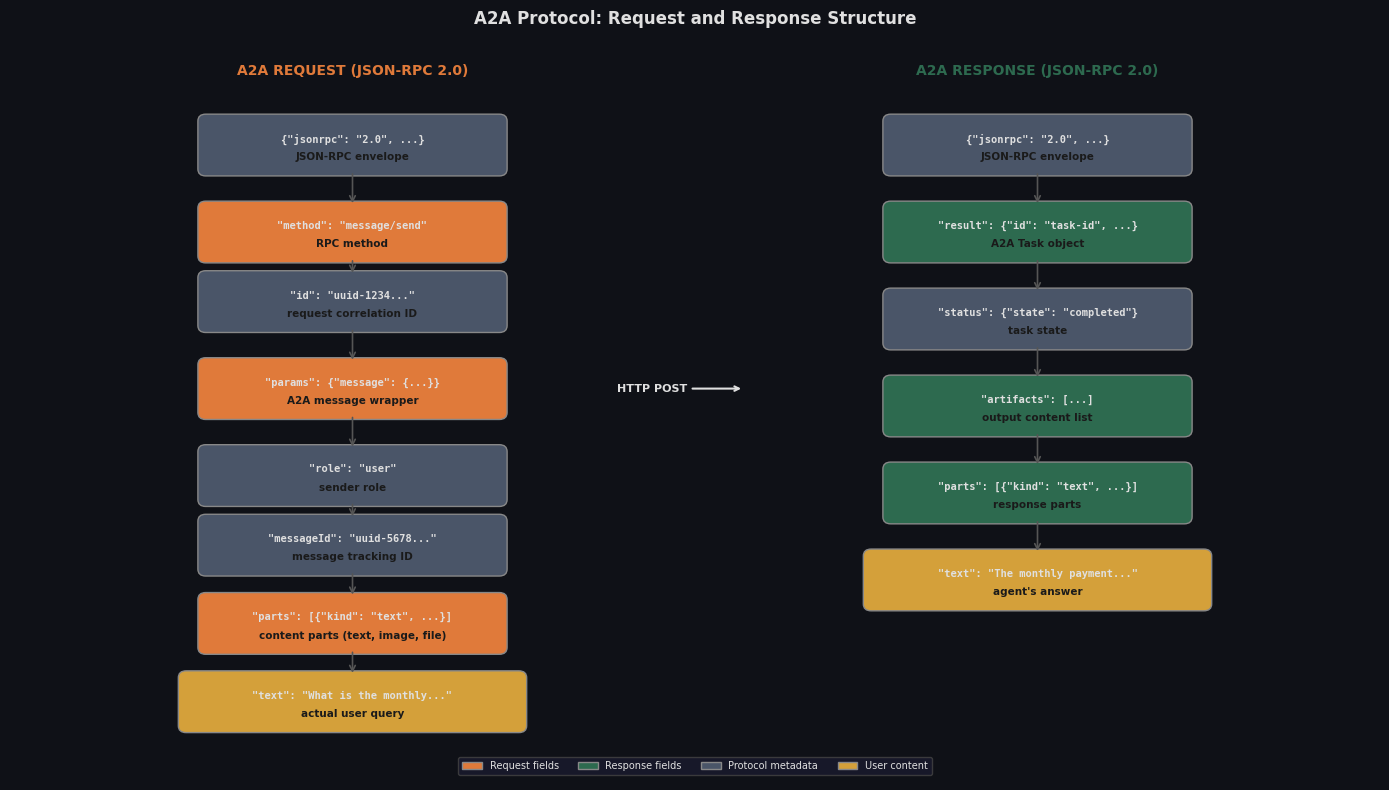

In [11]:
# -----------------------------------------------------------------------
# A2A protocol flow visualisation
# -----------------------------------------------------------------------

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 8.5)
ax.axis("off")
fig.patch.set_facecolor("#0f1117")

C_REQ  = "#e07a3a"
C_RESP = "#2d6a4f"
C_META = "#4a5568"
C_TEXT = "#e0e0e0"
C_EDGE = "#555555"
C_HL   = "#d4a03a"

def box(x, y, label, sublabel, color, w=3.0, h=0.55):
    rect = mpatches.FancyBboxPatch(
        (x - w / 2, y - h / 2), w, h,
        boxstyle="round,pad=0.08", facecolor=color,
        edgecolor="#888888", linewidth=1.0,
    )
    ax.add_patch(rect)
    ax.text(x, y + 0.07, label, ha="center", va="center",
            fontsize=7.5, fontweight="bold", color=C_TEXT, family="monospace")
    if sublabel:
        ax.text(x, y - 0.14, sublabel, ha="center", va="center",
                fontsize=7.5, fontweight="bold", color="#1a1a1a")

def edge(x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", color=C_EDGE, lw=1.2))

def bracket_label(x, y, text, color=C_HL):
    ax.text(x, y, text, ha="left", va="center",
            fontsize=7, fontweight="bold", color=color)

# -----------------------------------------------------------------------
# REQUEST side (left)
# -----------------------------------------------------------------------

ax.text(3.5, 8.1, "A2A REQUEST (JSON-RPC 2.0)", ha="center", fontsize=10,
        fontweight="bold", color=C_REQ)

box(3.5, 7.3, '{"jsonrpc": "2.0", ...}', "JSON-RPC envelope", C_META)

box(3.5, 6.3, '"method": "message/send"', "RPC method", C_REQ)
box(3.5, 5.5, '"id": "uuid-1234..."', "request correlation ID", C_META)

box(3.5, 4.5, '"params": {"message": {...}}', "A2A message wrapper", C_REQ)

box(3.5, 3.5, '"role": "user"', "sender role", C_META)
box(3.5, 2.7, '"messageId": "uuid-5678..."', "message tracking ID", C_META)

box(3.5, 1.8, '"parts": [{"kind": "text", ...}]', "content parts (text, image, file)", C_REQ)

box(3.5, 0.9, '"text": "What is the monthly..."', "actual user query", C_HL, w=3.4)

edge(3.5, 7.0, 3.5, 6.6)
edge(3.5, 6.0, 3.5, 5.8)
edge(3.5, 5.2, 3.5, 4.8)
edge(3.5, 4.2, 3.5, 3.8)
edge(3.5, 3.2, 3.5, 3.0)
edge(3.5, 2.4, 3.5, 2.1)
edge(3.5, 1.5, 3.5, 1.2)

# -----------------------------------------------------------------------
# Arrow between request and response
# -----------------------------------------------------------------------

ax.annotate("HTTP POST", xy=(7.5, 4.5), xytext=(6.2, 4.5),
            fontsize=8, fontweight="bold", color=C_TEXT,
            arrowprops=dict(arrowstyle="->", color=C_TEXT, lw=1.5),
            va="center")

# -----------------------------------------------------------------------
# RESPONSE side (right)
# -----------------------------------------------------------------------

ax.text(10.5, 8.1, "A2A RESPONSE (JSON-RPC 2.0)", ha="center", fontsize=10,
        fontweight="bold", color=C_RESP)

box(10.5, 7.3, '{"jsonrpc": "2.0", ...}', "JSON-RPC envelope", C_META)

box(10.5, 6.3, '"result": {"id": "task-id", ...}', "A2A Task object", C_RESP)

box(10.5, 5.3, '"status": {"state": "completed"}', "task state", C_META)

box(10.5, 4.3, '"artifacts": [...]', "output content list", C_RESP)

box(10.5, 3.3, '"parts": [{"kind": "text", ...}]', "response parts", C_RESP)

box(10.5, 2.3, '"text": "The monthly payment..."', "agent's answer", C_HL, w=3.4)

edge(10.5, 7.0, 10.5, 6.6)
edge(10.5, 6.0, 10.5, 5.6)
edge(10.5, 5.0, 10.5, 4.6)
edge(10.5, 4.0, 10.5, 3.6)
edge(10.5, 3.0, 10.5, 2.6)

# -----------------------------------------------------------------------
# Legend
# -----------------------------------------------------------------------

legend_items = [
    mpatches.Patch(facecolor=C_REQ, edgecolor="#888", label="Request fields"),
    mpatches.Patch(facecolor=C_RESP, edgecolor="#888", label="Response fields"),
    mpatches.Patch(facecolor=C_META, edgecolor="#888", label="Protocol metadata"),
    mpatches.Patch(facecolor=C_HL, edgecolor="#888", label="User content"),
]
ax.legend(handles=legend_items, loc="lower center", fontsize=7,
          facecolor="#1a1a2e", edgecolor="#444", labelcolor=C_TEXT, ncol=4)

ax.set_title("A2A Protocol: Request and Response Structure",
             fontsize=12, fontweight="bold", color=C_TEXT, pad=12)

plt.tight_layout()
plt.savefig("a2a_protocol_flow.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

### 4. LangGraph Orchestrator

A LangGraph `StateGraph` that coordinates calls to the three remote ADK
agents. The graph has four nodes: a router that decides which agents to
call, and one node per A2A specialist. The router uses Gemini via
`langchain-google-genai` to make the routing decision.

In [15]:
from langgraph.graph import StateGraph, END
from langchain_google_genai import ChatGoogleGenerativeAI

from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / "environment" / ".env")

# -----------------------------------------------------------------------
# State schema for the graph
# -----------------------------------------------------------------------

class OrchestratorState(TypedDict):
    query: str
    plan: str
    mortgage_result: str
    risk_result: str
    investment_result: str
    final_answer: str

# -----------------------------------------------------------------------
# LLM for routing and synthesis
# -----------------------------------------------------------------------

llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview",
    google_api_key=os.environ.get("GOOGLE_API_KEY"),
)

# -----------------------------------------------------------------------
# Node functions
# -----------------------------------------------------------------------

def plan_node(state: OrchestratorState) -> dict:
    """Decide which agents to call based on the query."""
    response = llm.invoke(
        f"Given this financial query, determine which of these agents "
        f"should be called (list all that apply): "
        f"mortgage (for payments, affordability), "
        f"risk (for credit/loan risk assessment), "
        f"investment (for compound interest, ROI, savings). "
        f"Reply with ONLY a comma-separated list of agent names, "
        f"nothing else.\n\nQuery: {state['query']}"
    )
    
    # response.content is returning a list instead of a string in langchain-google-genai
    content = response.content if isinstance(response.content, str) else response.content[0]["text"]
    plan = content.strip().lower()
    log.info("[planner] plan: %s", plan)
    return {"plan": plan}


def mortgage_node(state: OrchestratorState) -> dict:
    """Call the remote ADK mortgage agent via A2A."""
    if "mortgage" not in state.get("plan", ""):
        return {"mortgage_result": ""}
    log.info("[langgraph] calling mortgage A2A agent")
    result = call_a2a_agent("http://localhost:8001", state["query"])
    log.info("[langgraph] mortgage result received")
    return {"mortgage_result": result}


def risk_node(state: OrchestratorState) -> dict:
    """Call the remote ADK risk agent via A2A."""
    if "risk" not in state.get("plan", ""):
        return {"risk_result": ""}
    log.info("[langgraph] calling risk A2A agent")
    result = call_a2a_agent("http://localhost:8002", state["query"])
    log.info("[langgraph] risk result received")
    return {"risk_result": result}


def investment_node(state: OrchestratorState) -> dict:
    """Call the remote ADK investment agent via A2A."""
    if "investment" not in state.get("plan", ""):
        return {"investment_result": ""}
    log.info("[langgraph] calling investment A2A agent")
    result = call_a2a_agent("http://localhost:8003", state["query"])
    log.info("[langgraph] investment result received")
    return {"investment_result": result}


def synthesise_node(state: OrchestratorState) -> dict:
    """Synthesise results from all agents into a final answer."""
    parts = []
    if state.get("mortgage_result"):
        parts.append(f"Mortgage Analysis:\n{state['mortgage_result']}")
    if state.get("risk_result"):
        parts.append(f"Risk Assessment:\n{state['risk_result']}")
    if state.get("investment_result"):
        parts.append(f"Investment Projection:\n{state['investment_result']}")

    if not parts:
        return {"final_answer": "No relevant agents were called."}

    combined = "\n\n".join(parts)
    response = llm.invoke(
        f"You are a senior financial advisor. Synthesise the following "
        f"specialist reports into a single, clear recommendation. "
        f"Be concise and professional.\n\n"
        f"Original question: {state['query']}\n\n"
        f"Reports:\n{combined}"
    )

    # response.content is returning a list instead of a string in langchain-google-genai
    content = response.content if isinstance(response.content, str) else response.content[0]["text"]   
    return {"final_answer": content}


# -----------------------------------------------------------------------
# Build the graph
# -----------------------------------------------------------------------

graph = StateGraph(OrchestratorState)

graph.add_node("planner", plan_node)
graph.add_node("mortgage", mortgage_node)
graph.add_node("risk", risk_node)
graph.add_node("investment", investment_node)
graph.add_node("synthesise", synthesise_node)

graph.set_entry_point("planner")
graph.add_edge("planner", "mortgage")
graph.add_edge("planner", "risk")
graph.add_edge("planner", "investment")
graph.add_edge("mortgage", "synthesise")
graph.add_edge("risk", "synthesise")
graph.add_edge("investment", "synthesise")
graph.add_edge("synthesise", END)

orchestrator = graph.compile()

### 5. Test: Single-Domain Query

In [16]:
result = orchestrator.invoke({
    "query": "What is the monthly payment on a 400k house with 80k down at 6.5% for 30 years?",
    "plan": "", "mortgage_result": "", "risk_result": "",
    "investment_result": "", "final_answer": "",
})
display(Markdown(f"**LangGraph Orchestrator:**\n\n{result['final_answer']}"))

06:18:32  INFO      AFC is enabled with max remote calls: 10.
06:18:34  INFO      HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3-flash-preview:generateContent "HTTP/1.1 200 OK"
06:18:34  INFO      [planner] plan: mortgage
06:18:34  INFO      [langgraph] calling mortgage A2A agent
06:18:34  INFO      --- A2A REQUEST to http://localhost:8001 ---
06:18:34  INFO      method: message/send
06:18:34  INFO      message: What is the monthly payment on a 400k house with 80k down at 6.5% for 30 years?
06:18:34  INFO      payload:
{
  "jsonrpc": "2.0",
  "id": "a3de30f9-68cf-45db-b019-5ba1c9b75040",
  "method": "message/send",
  "params": {
    "message": {
      "role": "user",
      "parts": [
        {
          "kind": "text",
          "text": "What is the monthly payment on a 400k house with 80k down at 6.5% for 30 years?"
        }
      ],
      "messageId": "6c623f04-1e79-49cb-8e29-0e158dea91da"
    }
  }
}
06:18:38  INFO      HTTP Request: POST http:/

**LangGraph Orchestrator:**

**Executive Summary: Mortgage Financing Analysis**

For a property purchase of $400,000 with a 20% down payment ($80,000), the financial obligations are as follows:

*   **Loan Principal:** $320,000
*   **Monthly Principal & Interest (P&I):** $2,022.62
*   **Interest Rate:** 6.5% (Fixed)
*   **Term:** 30 Years

**Advisor Recommendation:**
Your monthly P&I commitment is **$2,022.62**. Please note that by providing a 20% down payment, you effectively avoid Private Mortgage Insurance (PMI), optimizing your monthly cash flow. 

However, when budgeting, you must account for "TITI" (Taxes, Insurance, and Total Interest). This P&I figure does **not** include property taxes, homeowners insurance, or potential HOA fees, which typically add 20–30% to the monthly obligation. Given that the total interest paid over the life of the loan ($408,142) exceeds the original principal, I recommend considering periodic principal curtailments to reduce the long-term interest burden if your cash flow permits.

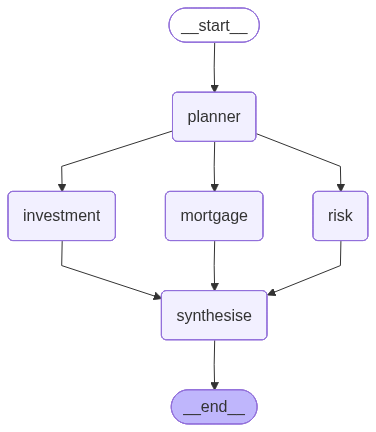

In [ ]:
from IPython.display import Image

try:
    display(Image(orchestrator.get_graph().draw_mermaid_png()))
except Exception:
    print(orchestrator.get_graph().draw_mermaid())

### 6. Test: Multi-Domain Query

In [18]:
result = orchestrator.invoke({
    "query": (
        "I earn 120k/year, have 500/mo debts, credit score 720. "
        "I want to buy a 450k house with 80k down at 6.5%. "
        "Also, what would 80k invested at 7% for 15 years grow to?"
    ),
    "plan": "", "mortgage_result": "", "risk_result": "",
    "investment_result": "", "final_answer": "",
})
display(Markdown(f"**LangGraph Orchestrator:**\n\n{result['final_answer']}"))

06:20:57  INFO      AFC is enabled with max remote calls: 10.
06:20:59  INFO      HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3-flash-preview:generateContent "HTTP/1.1 200 OK"
06:20:59  INFO      [planner] plan: mortgage, risk, investment
06:20:59  INFO      [langgraph] calling investment A2A agent
06:20:59  INFO      [langgraph] calling mortgage A2A agent
06:20:59  INFO      [langgraph] calling risk A2A agent
06:20:59  INFO      --- A2A REQUEST to http://localhost:8003 ---
06:20:59  INFO      --- A2A REQUEST to http://localhost:8001 ---
06:20:59  INFO      method: message/send
06:20:59  INFO      method: message/send
06:20:59  INFO      --- A2A REQUEST to http://localhost:8002 ---
06:20:59  INFO      message: I earn 120k/year, have 500/mo debts, credit score 720. I want to buy a 450k house with 80k down at 6.5%. Also, what would 80k invested at 7% for 15 ye
06:20:59  INFO      message: I earn 120k/year, have 500/mo debts, credit score 720. I want 

**LangGraph Orchestrator:**

**Executive Summary: Home Purchase & Investment Analysis**

Based on the specialist reports provided, you are in a strong financial position to proceed with the purchase of a $450,000 home. Below is the synthesis of the mortgage feasibility and the requested investment projection.

### 1. Mortgage & Affordability Analysis
Your proposed purchase is well within your means. With a gross monthly income of $10,000 and existing debts of $500, your financials are as follows:

*   **Loan Details:** A $370,000 loan (after an $80,000 down payment) at 6.5% results in a **Principal & Interest (P&I) payment of $2,338.65.**
*   **Total Monthly Obligations:** Including taxes, insurance, and existing debt, your estimated monthly outflow will be approximately **$3,438**.
*   **Debt-to-Income (DTI):** Your DTI ratio stands at **34.4%**, significantly below the 43% industry threshold for conventional lending. You are well-positioned for approval with a 720 credit score.

### 2. Investment Projection
If you were to invest the $80,000 down payment into a market-based account rather than real estate:
*   **15-Year Growth:** At a 7% annual return (compounded monthly), your $80,000 would grow to approximately **$227,916**.
*   **Total Gain:** This represents a capital gain of roughly **$147,916** over 15 years.

### 3. Professional Recommendation
**Proceed with the home purchase.** 

While the $80,000 has significant growth potential in the stock market, the home purchase is highly affordable given your income. You are trading potential market returns for home equity, tax advantages, and the stability of homeownership. 

**Strategic Notes:**
*   **Down Payment:** At 17.8% down, you are close to the 20% threshold. If liquidity allows, increasing your down payment to 20% ($90,000) would eliminate Private Mortgage Insurance (PMI), further lowering your monthly costs.
*   **Opportunity Cost:** At 6.5% interest, your mortgage rate is nearly equal to your projected 7% investment return. Paying down the mortgage (or using a large down payment) offers a "guaranteed" return of 6.5% by avoiding interest, which is a lower-risk strategy than the volatile stock market.

**Conclusion:** You have the clear financial capacity to support this mortgage while maintaining a healthy debt profile.

### 7. Shutdown

In [ ]:
for name, proc in processes.items():
    proc.terminate()
    proc.wait(timeout=5)
    log.info("stopped %s (pid=%d)", name, proc.pid)

processes.clear()
log.info("All A2A servers stopped.")

06:22:25  INFO      All A2A servers stopped.
